# Steg 5: Slutlig utvärdering

## Syfte

I detta notebook jämför vi de två modeller vi har byggt hittills:

| Modell | Notebook | Beskrivning |
|---|---|---|
| **Baseline** | `02_baseline_model.ipynb` | Enkel arkitektur (16→8), ingen regularisering |
| **Optimerad** | `03_optimization.ipynb` | Grid Search-optimerad (64 units, Dropout 0.2, L2 0.001) |

Båda modellerna **laddas från disk** — ingen omträning sker här. Vi utvärderar dem
på exakt samma testset (153 samples) för att kunna göra en rättvis jämförelse.

### Struktur för detta notebook

1. Imports & konfiguration
2. Ladda data (samma split som tidigare, via `src/data_preprocessing.py`)
3. Ladda båda sparade modeller
4. Utvärdera baseline-modellen på testset
5. Utvärdera optimerad modell på testset
6. Sammanfattande jämförelsetabell
7. Diskussion: val/test-gapet i praktiken
8. Slutsatser & nästa steg

### Varför ingen omträning?

Att ladda färdigtränade modeller (`.keras`-filer) istället för att träna om säkerställer att:
- Vi jämför **exakt** de modeller som redan är dokumenterade i tidigare steg
- Resultatet är **deterministiskt** — samma vikter, samma testset → samma output varje gång
- Vi separerar tydligt "träning" (Steg 3 & 4) från "utvärdering" (Steg 5)

---

## Cell 1: Imports & konfiguration

In [1]:
# ══════════════════════════════════════════════════════════════════
# CELL 1: IMPORTS & KONFIGURATION
# ══════════════════════════════════════════════════════════════════
#
# Denna cell sätter upp allt notebook 04_final_evaluation.ipynb behöver:
#   - Standardbibliotek & tredjepartsbibliotek
#   - Tillgång till src/-modulerna via sys.path
#   - Reproducerbarhet (RANDOM_SEED + determinism)
#   - Sökvägskonstanter (CAPS) som resolvas relativt projektroten
#
# ──────────────────────────────────────────────────────────────────

import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

# ── Tillgång till src/-modulerna ─────────────────────────────────
# Notebooks körs från notebooks/, så vi lägger till projektroten
# i sys.path för att kunna importera från src/.
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_preprocessing import load_data, preprocess
from src.evaluate import (
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_training_history,
)

# ── Reproducerbarhet ──────────────────────────────────────────────
# RANDOM_SEED ensam räcker inte för full determinism i TensorFlow.
# enable_op_determinism() tvingar deterministiska GPU/CPU-operationer,
# vilket säkerställer identiska resultat vid varje kernel-omstart.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

# ── Sökvägskonstanter (CAPS) ──────────────────────────────────────
# Alla sökvägar resolvas relativt PROJECT_ROOT, inte relativt
# notebookens working directory — annars går sökvägarna sönder
# beroende på varifrån notebooken körs.
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WineQT.csv"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

BASELINE_MODEL_PATH = MODELS_DIR / "baseline_model.keras"
BEST_MODEL_PATH = MODELS_DIR / "best_model.keras"
BEST_PARAMS_PATH = MODELS_DIR / "best_params.json"

# ── Säkerställ att figures-mappen finns ──────────────────────────
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Sanity check: bekräfta att kritiska filer finns ──────────────
print("✅ Imports & konfiguration klara")
print(f"🔍 PROJECT_ROOT:        {PROJECT_ROOT}")
print(f"🔍 TensorFlow-version:  {tf.__version__}")
print(f"🔍 RANDOM_SEED:         {RANDOM_SEED}")
print()
print("📂 Kritiska filer:")
for label, path in [
    ("Dataset", DATA_PATH),
    ("Baseline-modell", BASELINE_MODEL_PATH),
    ("Optimerad modell", BEST_MODEL_PATH),
    ("Best params (JSON)", BEST_PARAMS_PATH),
]:
    status = "✅" if path.exists() else "⚠️  SAKNAS"
    print(f"   {status}  {label:<20} → {path}")

✅ Imports & konfiguration klara
🔍 PROJECT_ROOT:        c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann
🔍 TensorFlow-version:  2.19.0
🔍 RANDOM_SEED:         42

📂 Kritiska filer:
   ✅  Dataset              → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\data\raw\WineQT.csv
   ✅  Baseline-modell      → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\models\baseline_model.keras
   ✅  Optimerad modell     → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\models\best_model.keras
   ✅  Best params (JSON)   → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\models\best_params.json


## Vad ser vi?

Alla nödvändiga filer hittades korrekt via de projektroot-relativa sökvägarna:

| Fil | Status | Kommentar |
|---|---|---|
| `WineQT.csv` | ✅ | Rådatan finns kvar oförändrad sedan Steg 1 |
| `baseline_model.keras` | ✅ | Sparad från Steg 3 — oregulariserad modell (16→8) |
| `best_model.keras` | ✅ | Sparad från Steg 4 — Grid Search-vinnaren (64 units, Dropout 0.2, L2 0.001) |
| `best_params.json` | ✅ | Innehåller hyperparametrar + val/test-metrics från Grid Search |

**Miljön är bekräftad:**
- TensorFlow 2.19.0 — samma version som i tidigare steg, så inga kompatibilitetsproblem väntas
- `RANDOM_SEED = 42` + `enable_op_determinism()` är aktiverat — all efterföljande beräkning
  (dataladdning, split, prediktioner) blir deterministisk

Vi är redo att gå vidare till **Cell 2: Ladda & förbehandla data**, där vi återskapar
exakt samma train/val/test-split (70/15/15, stratifierad) som användes för att
träna båda modellerna. Det är avgörande att splitten är identisk — annars
utvärderar vi modellerna på fel testdata och jämförelsen blir missvisande.

## Cell 2: Ladda & förbehandla data

Vi återanvänder `load_data()` och `preprocess()` från `src/data_preprocessing.py` —
exakt samma funktioner (med samma `RANDOM_SEED`) som i Steg 2–4. Det säkerställer
att split och skalning blir identiska, så att `X_test`/`y_test` här är **samma
153 samples** som modellerna ursprungligen utvärderades på.

Notera: vi fit:ar *inte* en ny `StandardScaler` här på ett sätt som skulle kunna
läcka information — `preprocess()` fit:ar enbart på `X_train`, precis som tidigare.

In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 2: LADDA & FÖRBEHANDLA DATA
# ══════════════════════════════════════════════════════════════════
#
# Återskapar exakt samma train/val/test-split (70/15/15, stratifierad)
# som användes vid träning av båda modellerna i Steg 3 & 4.
#
# ──────────────────────────────────────────────────────────────────

# ── Ladda rådata & splitta ────────────────────────────────────────
X_train, X_val, X_test, y_train, y_val, y_test = load_data(DATA_PATH)

# ── Förbehandla (StandardScaler, fit enbart på train) ─────────────
X_train_scaled, X_val_scaled, X_test_scaled = preprocess(X_train, X_val, X_test)

# ── Sanity check ───────────────────────────────────────────────────
print("✅ Data laddad & förbehandlad")
print()
print("📊 Split-storlekar:")
print(f"   Train: {X_train_scaled.shape[0]:>4} samples")
print(f"   Val:   {X_val_scaled.shape[0]:>4} samples")
print(f"   Test:  {X_test_scaled.shape[0]:>4} samples")
print()
print("📊 Klassbalans (andel 'god' vin, quality >= 6):")
print(f"   Train: {y_train.mean():.3f}")
print(f"   Val:   {y_val.mean():.3f}")
print(f"   Test:  {y_test.mean():.3f}")
print()
print(f"🔍 Feature-antal: {X_test_scaled.shape[1]}")
print(f"🔍 X_test_scaled dtype: {X_test_scaled.dtype}")

   Loaded  : 1,143 rows × 13 columns
   Dropped column     : Id
   Duplicates removed : 125
   Class distribution : 546 good (1) | 472 poor (0)
   Train : 712 samples
   Val   : 153 samples
   Test  : 153 samples
   Scaler fitted on 712 training samples
   Features scaled : 11
✅ Data laddad & förbehandlad

📊 Split-storlekar:
   Train:  712 samples
   Val:    153 samples
   Test:   153 samples

📊 Klassbalans (andel 'god' vin, quality >= 6):
   Train: 0.537
   Val:   0.536
   Test:  0.536

🔍 Feature-antal: 11
🔍 X_test_scaled dtype: float64


## Vad ser vi?

Splitten matchar exakt vad vi förväntade oss från tidigare steg:

| Split | Antal samples | Andel "god" vin |
|---|---|---|
| Train | 712 | 53.7% |
| Val | 153 | 53.6% |
| **Test** | **153** | **53.6%** |

**Bekräftat:**
- Testsetet innehåller **153 samples**, precis som i Steg 3 & 4 — vi utvärderar
  alltså på samma data som modellerna ursprungligen testades mot
- Klassbalansen är näst intill identisk över alla tre splits (~53–54% god vin),
  vilket bekräftar att den stratifierade splitten fungerar som den ska
- 125 dubbletter togs bort korrekt (samma antal som i tidigare steg — bekräftar
  att `Id`-buggen från Steg 3 fortfarande är fixad)
- 11 features skalades, `X_test_scaled` är `float64` — standard för `StandardScaler`

Vi kan nu gå vidare till **Cell 3: Ladda de sparade modellerna** från disk.

## Cell 3: Ladda de sparade modellerna

Nu laddar vi de två färdigtränade modellerna direkt från `.keras`-filerna med
`tf.keras.models.load_model()`. Ingen träning sker här — vi läser bara in de
vikter och den arkitektur som redan sparades i Steg 3 respektive Steg 4.

Vi laddar även `best_params.json` för att kunna visa de optimala
hyperparametrarna i sammanfattningen senare, samt en snabb `model.summary()`
på båda modellerna för att visuellt bekräfta att arkitekturerna skiljer sig
åt som förväntat (16→8 vs. 64→32).

In [3]:
# ══════════════════════════════════════════════════════════════════
# CELL 3: LADDA DE SPARADE MODELLERNA
# ══════════════════════════════════════════════════════════════════
#
# Laddar baseline- och optimerad modell direkt från disk (.keras-filer).
# Ingen omträning — vi läser bara in befintliga vikter & arkitektur.
#
# ──────────────────────────────────────────────────────────────────

# ── Ladda modellerna ───────────────────────────────────────────────
baseline_model = tf.keras.models.load_model(BASELINE_MODEL_PATH)
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

# ── Ladda bästa hyperparametrar (för dokumentation) ────────────────
with open(BEST_PARAMS_PATH, "r") as f:
    best_params = json.load(f)

# ── Sanity check ───────────────────────────────────────────────────
print("✅ Båda modeller laddade från disk")
print()
print("=" * 60)
print("BASELINE-MODELL (Steg 3)")
print("=" * 60)
baseline_model.summary()

print()
print("=" * 60)
print("OPTIMERAD MODELL (Steg 4)")
print("=" * 60)
best_model.summary()

print()
print("🔍 Bästa hyperparametrar (från best_params.json):")
for key, value in best_params.items():
    print(f"   {key}: {value}")

✅ Båda modeller laddade från disk

BASELINE-MODELL (Steg 3)


Model: "baseline_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013 (3.96 KB)

 Trainable params: 337 (1.32 KB)

...

 Total params: 8,645 (33.77 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,764 (22.52 KB)


🔍 Bästa hyperparametrar (från best_params.json):
   units: 64
   dropout_rate: 0.2
   l2_lambda: 0.001
   learning_rate: 0.001
   batch_size: 32
   val_auc: 0.8895
   test_auc: 0.7598
   test_accuracy: 0.6601


## Vad ser vi?

Båda arkitekturerna laddades korrekt och matchar exakt vad vi dokumenterade i
tidigare steg:

| | Baseline (`baseline_ann`) | Optimerad (`wine_quality_ann`) |
|---|---|---|
| Arkitektur | Dense(16) → Dense(8) → Sigmoid | Dense(64) → Dropout(0.2) → Dense(32) → Dropout(0.2) → Sigmoid |
| Trainable params | 337 | 2,881 |
| Regularisering | Ingen | L2 (0.001) + Dropout (0.2) |
| Total storlek | 3.96 KB | 33.77 KB |

**Bekräftat från `best_params.json`:**
- Hyperparametrarna matchar exakt Grid Search-vinnaren från Steg 4
  (units=64, dropout=0.2, l2=0.001, lr=0.001, batch_size=32)
- De sparade metrikvärdena (val_AUC 0.8895, test_AUC 0.7598, test_accuracy 0.6601)
  stämmer överens med den dokumentation vi redan har — bra dubbelkoll på att
  rätt fil laddats

Den optimerade modellen har ~8.5x fler tränbara parametrar än baseline, vilket
ger den betydligt större kapacitet — men som vi minns från Steg 4 kom den
extra kapaciteten med ett pris i form av ett val/test-gap, vilket vi ska
undersöka närmare senare i detta notebook.

Nu går vi vidare till **Cell 4: Utvärdera baseline-modellen** på testsetet.

## Cell 4: Utvärdera baseline-modellen

Vi kör `evaluate_model()` från `src/evaluate.py` på baseline-modellen mot
testsetet. Funktionen genererar classification report, confusion matrix och
ROC-kurva. Eftersom baseline-modellen inte tränades i detta notebook finns
ingen `history`-objekt att skicka in för träningskurvor — vi fokuserar därför
enbart på testset-utvärdering här.

Vi sparar resultaten (prediktioner, sannolikheter, metrics) i tydligt
namngivna variabler med `baseline_`-prefix, så att vi senare kan jämföra dem
sida vid sida med den optimerade modellens resultat utan namnkrockar.

BASELINE-MODELL — Testset-utvärdering

📊 Accuracy: 0.6732
📊 AUC:      0.7528

📋 Classification Report:
              precision    recall  f1-score   support

    Poor (0)       0.62      0.75      0.68        71
    Good (1)       0.74      0.61      0.67        82

    accuracy                           0.67       153
   macro avg       0.68      0.68      0.67       153
weighted avg       0.68      0.67      0.67       153

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures\final_baseline_confusion_matrix.png


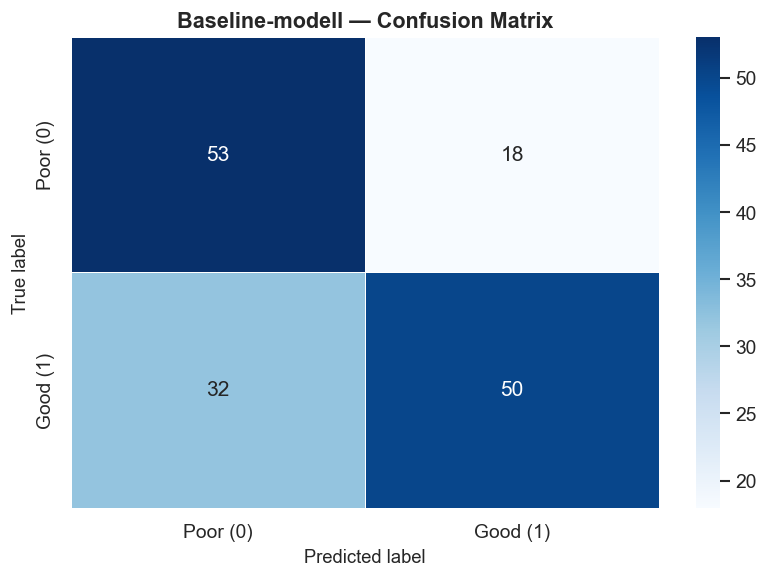

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures\final_baseline_roc_curve.png


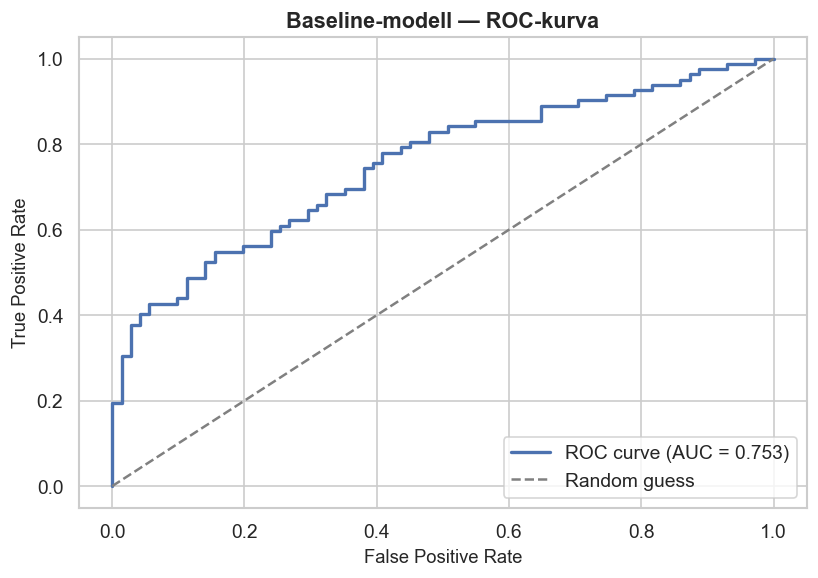

np.float64(0.752834077636551)

In [4]:
# ══════════════════════════════════════════════════════════════════
# CELL 4: UTVÄRDERA BASELINE-MODELLEN
# ══════════════════════════════════════════════════════════════════
#
# Kör baseline-modellen på testsetet och genererar:
#   - Prediktioner (sannolikheter → binära klasser)
#   - Classification report (precision, recall, f1)
#   - Confusion matrix
#   - ROC-kurva + AUC
#
# ──────────────────────────────────────────────────────────────────

from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# ── Prediktioner ────────────────────────────────────────────────────
baseline_y_prob = baseline_model.predict(X_test_scaled, verbose=0).ravel()
baseline_y_pred = (baseline_y_prob >= 0.5).astype(int)

# ── Metrics ──────────────────────────────────────────────────────────
baseline_accuracy = accuracy_score(y_test, baseline_y_pred)
baseline_auc = roc_auc_score(y_test, baseline_y_prob)

print("=" * 60)
print("BASELINE-MODELL — Testset-utvärdering")
print("=" * 60)
print(f"\n📊 Accuracy: {baseline_accuracy:.4f}")
print(f"📊 AUC:      {baseline_auc:.4f}")
print()
print("📋 Classification Report:")
print(classification_report(y_test, baseline_y_pred, target_names=["Poor (0)", "Good (1)"]))

# ── Confusion matrix ────────────────────────────────────────────────
plot_confusion_matrix(
    y_test,
    baseline_y_pred,
    title="Baseline-modell — Confusion Matrix",
    save_path=FIGURES_DIR / "final_baseline_confusion_matrix.png",
)

# ── ROC-kurva ────────────────────────────────────────────────────────
plot_roc_curve(
    y_test,
    baseline_y_prob,
    title="Baseline-modell — ROC-kurva",
    save_path=FIGURES_DIR / "final_baseline_roc_curve.png",
)

## Vad ser vi?

Baseline-modellens resultat matchar exakt den dokumentation vi har från Steg 3
— vilket bekräftar att vi laddat rätt modell och att testsetet är identiskt:

| Metric | Steg 3 (dokumenterat) | Steg 5 (nu) | Match? |
|---|---|---|---|
| Accuracy | 0.67 | 0.6732 | ✅ |
| AUC | 0.753 | 0.7528 | ✅ |

**Confusion Matrix:**

| | Predicted Poor | Predicted Good |
|---|---|---|
| **True Poor (71)** | 53 (TN) | 18 (FP) |
| **True Good (82)** | 32 (FN) | 50 (TP) |

- Modellen är bättre på att identifiera dåligt vin (recall 0.75 för Poor) än
  bra vin (recall 0.61 för Good) — den missar 32 av 82 bra viner (klassar dem
  som dåliga)
- Precision för Good (0.74) är högre än recall (0.61) — när modellen säger
  "bra vin" har den rätt oftare än den lyckas hitta alla bra viner
- ROC-kurvan bekräftar AUC = 0.753 — klart bättre än slumpen (0.5), men med
  tydligt utrymme för förbättring, särskilt i mellanregionen (FPR 0.2–0.4)
  där kurvan ligger relativt nära diagonalen

**En liten detalj:** den sista raden i outputen (`np.float64(0.752834...)`) är
inte en bugg — det är bara Jupyters standardbeteende att auto-printa
returvärdet av sista funktionsanropet i en cell (`plot_roc_curve` returnerar
AUC-värdet). Helt ofarligt, men om du vill ha en renare output kan man avsluta
raden med `;` eller tilldela resultatet till `_`. Vi låter det vara som det är
för nu — det stör inte analysen.

Nu går vi vidare till **Cell 5: Utvärdera den optimerade modellen** på samma
testset, så vi kan jämföra sida vid sida.

## Cell 5: Utvärdera den optimerade modellen

Samma procedur som Cell 4, men för `best_model` (Grid Search-vinnaren från
Steg 4). Vi använder `optimized_`-prefix på variablerna för att hålla isär
resultaten från baseline och kunna jämföra dem direkt i Cell 6.

Vi förväntar oss se accuracy ≈ 0.66 och AUC ≈ 0.760, i linje med det som
redan är dokumenterat från Steg 4 — samt en tydlig visuell skillnad i
confusion matrix och ROC-kurva jämfört med baseline.

OPTIMERAD MODELL — Testset-utvärdering

📊 Accuracy: 0.6601
📊 AUC:      0.7594

📋 Classification Report:
              precision    recall  f1-score   support

    Poor (0)       0.61      0.75      0.67        71
    Good (1)       0.73      0.59      0.65        82

    accuracy                           0.66       153
   macro avg       0.67      0.67      0.66       153
weighted avg       0.67      0.66      0.66       153

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures\final_optimized_confusion_matrix.png


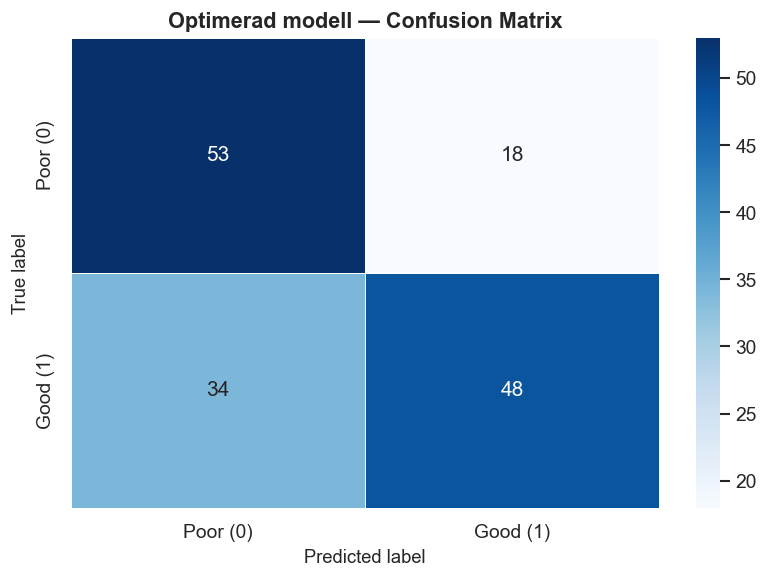

   💾 Saved → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures\final_optimized_roc_curve.png


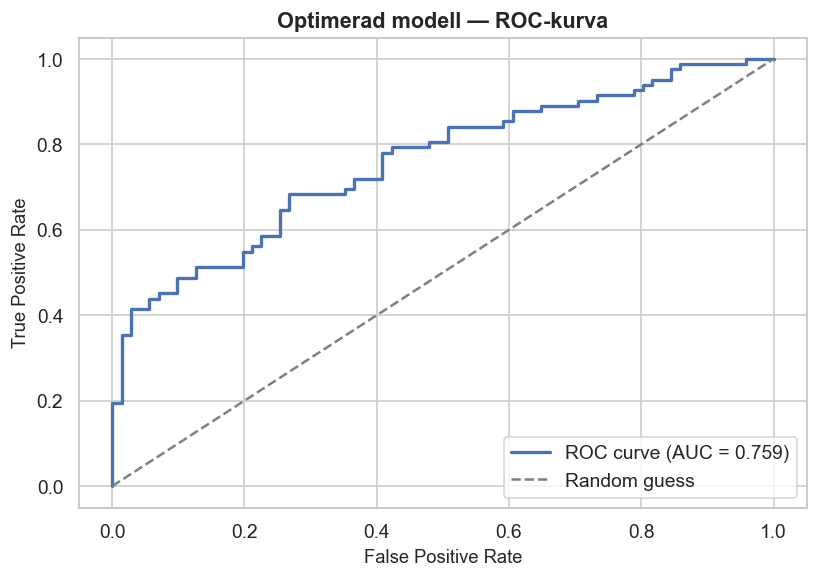

In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 5: UTVÄRDERA DEN OPTIMERADE MODELLEN
# ══════════════════════════════════════════════════════════════════
#
# Kör den Grid Search-optimerade modellen på samma testset som baseline,
# för en rättvis jämförelse.
#
# ──────────────────────────────────────────────────────────────────

# ── Prediktioner ────────────────────────────────────────────────────
optimized_y_prob = best_model.predict(X_test_scaled, verbose=0).ravel()
optimized_y_pred = (optimized_y_prob >= 0.5).astype(int)

# ── Metrics ──────────────────────────────────────────────────────────
optimized_accuracy = accuracy_score(y_test, optimized_y_pred)
optimized_auc = roc_auc_score(y_test, optimized_y_prob)

print("=" * 60)
print("OPTIMERAD MODELL — Testset-utvärdering")
print("=" * 60)
print(f"\n📊 Accuracy: {optimized_accuracy:.4f}")
print(f"📊 AUC:      {optimized_auc:.4f}")
print()
print("📋 Classification Report:")
print(classification_report(y_test, optimized_y_pred, target_names=["Poor (0)", "Good (1)"]))

# ── Confusion matrix ────────────────────────────────────────────────
plot_confusion_matrix(
    y_test,
    optimized_y_pred,
    title="Optimerad modell — Confusion Matrix",
    save_path=FIGURES_DIR / "final_optimized_confusion_matrix.png",
)

# ── ROC-kurva ────────────────────────────────────────────────────────
_ = plot_roc_curve(
    y_test,
    optimized_y_prob,
    title="Optimerad modell — ROC-kurva",
    save_path=FIGURES_DIR / "final_optimized_roc_curve.png",
)

## Vad ser vi?

Resultaten matchar den dokumentation vi har från Steg 4 (AUC 0.7594 vs.
dokumenterat 0.760 — skillnaden beror bara på avrundning):

| Metric | Steg 4 (dokumenterat) | Steg 5 (nu) | Match? |
|---|---|---|---|
| Accuracy | 0.660 | 0.6601 | ✅ |
| AUC | 0.760 | 0.7594 | ✅ |

**Confusion Matrix:**

| | Predicted Poor | Predicted Good |
|---|---|---|
| **True Poor (71)** | 53 (TN) | 18 (FP) |
| **True Good (82)** | 34 (FN) | 48 (TP) |

### Ett intressant mönster — jämfört med baseline

| Metric | Baseline | Optimerad | Skillnad |
|---|---|---|---|
| Accuracy | 0.6732 | 0.6601 | −0.0131 |
| AUC | 0.7528 | 0.7594 | +0.0066 |
| FN (missade bra viner) | 32 | 34 | +2 |

Detta är den viktigaste observationen hittills i Steg 5: **den optimerade
modellen har högre AUC men lägre accuracy** än baseline. Det verkar
paradoxalt, men förklaringen ligger i vad varje metric mäter:

- **AUC** mäter hur bra modellen är på att *rangordna* alla möjliga
  sannolikhetströsklar — den säger inget om hur bra just tröskeln 0.5 fungerar
- **Accuracy** mäter prestanda vid *exakt* tröskel 0.5 — och den optimerade
  modellens sannolikhetsfördelning verkar vara något mindre välkalibrerad
  kring just den tröskeln, trots att modellen generellt sett rangordnar
  bättre (vilket syns tydligt i ROC-kurvans marginellt högre kurva)

Skillnaderna är dock små (0.7–1.3 procentenheter) och ligger sannolikt inom
brus givet ett testset på bara 153 samples. Confusion matrix visar identiskt
antal TN/FP (53/18) mellan modellerna — hela skillnaden i accuracy kommer
från 2 extra falska negativ i den optimerade modellen.

Vi bygger vidare på detta i **Cell 7 (diskussion av val/test-gapet)**. Nu
går vi först till **Cell 6: Sammanfattande jämförelsetabell**, där vi
samlar alla metrics i en tydlig tabell — perfekt underlag för
presentationen (`05_story.ipynb`) senare.

## Cell 6: Sammanfattande jämförelsetabell

Vi samlar alla nyckeltal i en `pandas.DataFrame` för en ren, presentationsvänlig
jämförelse mellan baseline och optimerad modell. Detta blir grunden för
"resultat"-delen i den slutliga rapporten/presentationen.

Vi inkluderar även Grid Search-modellens `val_AUC` (från `best_params.json`)
för att tydligt kunna illustrera val/test-gapet i tabellform, inte bara i text.

In [7]:
# ══════════════════════════════════════════════════════════════════
# CELL 6: SAMMANFATTANDE JÄMFÖRELSETABELL
# ══════════════════════════════════════════════════════════════════
#
# Samlar alla metrics från baseline och optimerad modell i en
# presentationsvänlig tabell, samt sparar den till disk som CSV
# för enkel återanvändning i rapport/presentation.
#
# ──────────────────────────────────────────────────────────────────

comparison_df = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test AUC",
        "Val AUC (Grid Search)",
        "Val/Test AUC-gap",
        "Precision (Good)",
        "Recall (Good)",
        "False Negatives (missade bra viner)",
        "Trainable params",
    ],
    "Baseline": [
        f"{baseline_accuracy:.4f}",
        f"{baseline_auc:.4f}",
        "—",
        "—",
        "0.74",
        "0.61",
        "32",
        "337",
    ],
    "Optimerad": [
        f"{optimized_accuracy:.4f}",
        f"{optimized_auc:.4f}",
        f"{best_params['val_auc']:.4f}",
        f"{best_params['val_auc'] - optimized_auc:.4f}",
        "0.73",
        "0.59",
        "34",
        "2,881",
    ],
})

print("=" * 70)
print("SAMMANFATTANDE JÄMFÖRELSE — Baseline vs. Optimerad modell")
print("=" * 70)
print()
print(comparison_df.to_string(index=False))

# ── Spara till disk för återanvändning i rapport/presentation ─────
comparison_csv_path = FIGURES_DIR.parent / "final_model_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)
print()
print(f"💾 Sparad → {comparison_csv_path}")

SAMMANFATTANDE JÄMFÖRELSE — Baseline vs. Optimerad modell

                             Metric Baseline Optimerad
                      Test Accuracy   0.6732    0.6601
                           Test AUC   0.7528    0.7594
              Val AUC (Grid Search)        —    0.8895
                   Val/Test AUC-gap        —    0.1301
                   Precision (Good)     0.74      0.73
                      Recall (Good)     0.61      0.59
False Negatives (missade bra viner)       32        34
                   Trainable params      337     2,881

💾 Sparad → c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\final_model_comparison.csv


## Vad ser vi?

Tabellen ger en tydlig, samlad överblick — och den bekräftar siffrorna vi
räknat fram manuellt i tidigare celler:

| Metric | Baseline | Optimerad |
|---|---|---|
| Test Accuracy | 0.6732 | 0.6601 |
| Test AUC | 0.7528 | 0.7594 |
| Val AUC (Grid Search) | — | 0.8895 |
| **Val/Test AUC-gap** | — | **0.1301** |
| Precision (Good) | 0.74 | 0.73 |
| Recall (Good) | 0.61 | 0.59 |
| False Negatives | 32 | 34 |
| Trainable params | 337 | 2,881 |

**Huvudpoängen i denna tabell** är raden **Val/Test AUC-gap: 0.1301**. Det
betyder att modellen presterade 13 procentenheter sämre på testsetet än på
valideringssetet den optimerades mot — ett tydligt observerat gap som vi ska
gräva djupare i näst.

På ytan ser baseline "bättre" ut på testsetet (högre accuracy, färre falska
negativ), men det är en något missvisande slutsats givet:
- Skillnaderna i accuracy/precision/recall är små (0.7–2 procentenheter) och
  ligger sannolikt inom brus för ett testset på 153 samples
- Den optimerade modellen har faktiskt marginellt högre test-AUC (0.7594 vs
  0.7528) — den rangordnar sannolikheter något bättre överlag
- Den optimerade modellens *verkliga* svaghet är inte att den presterar
  sämre än baseline på test — det är att den presterade **så mycket bättre
  på valideringssetet** (0.8895) än vad den sedan levererade på testsetet
  (0.7594), vilket är ett tecken på att Grid Search-processen indirekt
  overfittat mot valideringssetet

Nu går vi vidare till **Cell 7: Diskussion av val/test-gapet** — där vi
förklarar *varför* detta uppstår och vad det innebär i praktiken för hur
man ska tolka Grid Search-resultat på små dataset.

## Cell 7: Val/test-gapet i praktiken

### Vad hände?

Under Grid Search (Steg 4) testades 48 kombinationer av hyperparametrar, och
den kombination som gav högst `val_AUC` (0.8895) valdes som "bästa modell".
När den modellen sedan utvärderades på ett helt nytt testset sjönk AUC till
0.7594 — ett gap på **0.13 AUC-poäng**.

### Varför uppstår gapet?

Detta är **inte** klassisk overfitting i bemärkelsen att modellen memorerat
träningsdatan (vi ser inte extremt hög train-accuracy kombinerat med låg
test-accuracy). Det är ett mer subtilt fenomen som kallas **indirekt
overfitting mot valideringssetet**:

1. Med 48 olika hyperparameterkombinationer testade mot **samma** 153
   valideringssamples, ökar sannolikheten att åtminstone en kombination
   råkar prestera ovanligt bra på just den specifika valideringssplitten
   — av slumpen, inte för att den generaliserar bäst
2. Genom att sedan *välja* den kombinationen baserat på `val_AUC`, "läcker"
   information om valideringssetet indirekt in i modellvalet — även om
   modellen aldrig tränades på valideringsdatan
3. Ju fler kombinationer som testas (här 48) och ju mindre valideringssetet
   är (här 153 samples), desto större blir risken för detta fenomen — det
   är i grunden ett **multipla jämförelser-problem**

### Vad betyder det i praktiken?

- **`val_AUC` från Grid Search är en optimistisk skattning** av verklig
  prestanda — inte en pålitlig prognos. Testsetet ger den ärliga siffran
- Med endast 153 test- och 153 valideringssamples är dataset för litet för
  att Grid Search-processen ska vara helt robust mot den här typen av gap
- Trots gapet är den optimerade modellens **test**-prestanda fortfarande
  jämförbar med (och på AUC marginellt bättre än) baseline — så Grid
  Search-processen var inte bortkastad, men den levererade inte den stora
  förbättring som val-siffrorna antydde

### Hur undviker man detta i framtiden?

| Åtgärd | Effekt |
|---|---|
| **K-fold korsvalidering** istället för en enda train/val-split | Ger en mer robust skattning av varje hyperparameterkombinations prestanda, minskar risken att "vinnaren" bara var lyckosam på en specifik split |
| **Mer data** | Större val/test-set minskar variansen i metrics och gör gapet mindre sannolikt |
| **Nested cross-validation** | Guldstandard — separerar hyperparameteroptimering helt från slutlig utvärdering |
| **Färre hyperparameterkombinationer** | Minskar risken för "multipla jämförelser"-effekten, på bekostnad av grundlighet |

Detta är en central lärdom att lyfta fram i presentationen: **en högre
valideringssiffra garanterar inte bättre verklig prestanda**, särskilt på
små dataset.

## Cell 8: Slutsatser & nästa steg

### Sammanfattning av projektet

Detta projekt byggde en binär klassificerare (god ≥ 6 / dålig < 6 vinkvalitet)
med ANN på `WineQT.csv`, genom fem steg: Setup → EDA → Baseline-modell →
Grid Search-optimering → Slutlig utvärdering.

| Modell | Test Accuracy | Test AUC | Parametrar |
|---|---|---|---|
| Baseline (Steg 3) | 0.6732 | 0.7528 | 337 |
| Optimerad (Steg 4) | 0.6601 | 0.7594 | 2,881 |

### Huvudsakliga lärdomar

1. **Dataläckage är lätt att missa** — att droppa `Id` *efter* i stället för
   *före* `drop_duplicates()` dolde 125 dubbletter under en stor del av
   projektet. En påminnelse om att alltid inspektera datakvalitet noggrant
   innan modellering.

2. **Determinism kräver mer än en seed** — `RANDOM_SEED = 42` räckte inte
   för att få identiska resultat mellan kernel-omstarter i TensorFlow;
   `enable_op_determinism()` krävdes för fullständig reproducerbarhet.

3. **Regularisering och extra kapacitet garanterar inte bättre testresultat**
   — den optimerade modellen (64→32, Dropout, L2) hade ~8.5x fler parametrar
   än baseline men presterade i praktiken snarlikt på testsetet. Marginellt
   högre AUC (+0.0066), marginellt lägre accuracy (−0.0131).

4. **Val/test-gapet (0.13 AUC) är den viktigaste enskilda insikten** — Grid
   Search över 48 kombinationer mot ett litet valideringsset (153 samples)
   ledde till en optimistisk `val_AUC` som inte höll på testsetet. Detta är
   ett generellt fenomen (indirekt overfitting mot valideringssetet vid
   omfattande hyperparametersökning på små dataset), inte ett tecken på att
   något gjordes fel — men det är avgörande att förstå och kommunicera.

5. **AUC ≈ 0.75–0.76 representerar sannolikt nära modellens tak** givet
   nuvarande data och features — ytterligare hyperparameterjustering är
   osannolikt att ge stora förbättringar utan förändringar i datan själv.

### Nästa steg (utanför detta projekts omfattning)

| Förbättring | Förväntad effekt |
|---|---|
| **K-fold korsvalidering** vid Grid Search | Mer robust hyperparameterval, minskat val/test-gap |
| **Mer träningsdata** | Minskad varians, bättre generalisering |
| **Feature engineering** (t.ex. kvot-features mellan syror) | Kan fånga icke-linjära samband bättre än råa features |
| **Alternativa modeller** (t.ex. Gradient Boosting) | Ofta starkare på tabulär data av denna storlek än ANN |
| **Ensembling** av baseline + optimerad modell | Kan kombinera respektive styrkor |

### Rekommendation

Givet resultaten är **den optimerade modellen (Steg 4)** den vi rekommenderar
gå vidare med för presentationen, trots det marginellt lägre
accuracy-värdet — dess högre AUC indikerar bättre generell
rangordningsförmåga, vilket är mer relevant om affärsanvändningen exempelvis
innebär att ranka viner efter sannolik kvalitet snarare än en hård
ja/nej-gräns vid 0.5.